# McNemar's Test — HyConDViT-Net vs Baselines (Primary Dataset)

**Standalone companion notebook to `HyConDViT_Net_PCOS_v3_Main.ipynb`.**

This notebook answers one question: *are the differences between HyConDViT-Net's
predictions and each baseline model's predictions on the **Primary** PCOS
ultrasound dataset statistically significant, sample-by-sample?*

**What "keeps everything the same":**
- Same Primary dataset source (`ibadeus/pcos-xai-ultrasound-dataset`) — the
  External validation dataset is **not** used in this notebook.
- Same augment-before-split methodology, same `AUG_MULTIPLIER=4`, same
  70/15/15 train/val/test split logic, same seeding (`set_seed`).
- Same model registry, architectures, and training hyperparameters.
- Same trained weights: this notebook does **not** retrain anything. It
  reloads the best checkpoint your main notebook already saved
  (`mc_checkpoint.pt` + `best_hyconDvit.pt`) and reconstructs the exact
  primary-dataset test split those weights were evaluated on — the same
  split behind your Fig 6–17 results.

**Prerequisite:** run the main notebook through at least the *Monte Carlo
Cross-Validation* cell (in this same working directory / Kaggle or Colab
session) so `mc_checkpoint.pt` and `best_hyconDvit.pt` exist on disk. If you
ran the main notebook somewhere else, copy those two files next to this
notebook, or edit `CKPT_DIR` in the checkpoint-loading cell below.

**A note on "First Primary dataset"** — I've read this as *the Primary
dataset* (as opposed to the External one), since that's how the main
notebook itself distinguishes "primary" vs "external". If you actually meant
a specific Monte Carlo run (e.g. run 1 by seed, rather than the best/
persisted run), tell me and I'll point the reconstruction at that seed
instead.

In [1]:
# GPU Status — Top of Notebook
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "nvidia-smi not available")

Sun Jul 26 14:42:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ── Environment detection + PRIMARY dataset resolution ─────────────
# (External dataset is intentionally NOT loaded in this notebook — McNemar's
#  test here is computed on the PRIMARY dataset only, i.e. the same held-out
#  test split used for the main notebook's Fig 6-17 results, NOT the
#  external-validation set.)
import os
import sys
import platform
import subprocess as _sp
from pathlib import Path

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

IN_COLAB   = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
IN_KAGGLE  = os.path.exists('/kaggle/input')
IN_JUPYTER = 'ipykernel' in sys.modules

if IN_COLAB:
    PLATFORM_NAME = "Google Colab"
elif IN_KAGGLE:
    PLATFORM_NAME = "Kaggle"
elif IN_JUPYTER:
    PLATFORM_NAME = "Jupyter Notebook / JupyterLab"
else:
    PLATFORM_NAME = "Local Python Environment"

print("="*60)
print("SYSTEM INFORMATION")
print("="*60)
print(f"Platform : {PLATFORM_NAME}")
print(f"OS       : {platform.system()} {platform.release()}")
print(f"Python   : {platform.python_version()}")

def _install(pkg_spec):
    _sp.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_spec])

# ── kagglehub install — pinned version, with fallback ────────────
KAGGLEHUB_OK = False
try:
    import kagglehub
    from kagglehub import dataset_download as _test_fn
    KAGGLEHUB_OK = True
except Exception as e:
    print(f"\nkagglehub import failed ({type(e).__name__}: {e})")
    print("Reinstalling kagglehub (pinned compatible version)...")
    try:
        _install('kagglehub==0.3.4')
        for mod in list(sys.modules):
            if mod.startswith('kagglehub') or mod.startswith('kagglesdk'):
                del sys.modules[mod]
        import kagglehub
        KAGGLEHUB_OK = True
        print("kagglehub reinstalled successfully.")
    except Exception as e2:
        print(f"kagglehub still broken: {e2}")
        print("Falling back to manual Kaggle dataset path (see DATA_ROOT override below).")
        KAGGLEHUB_OK = False

try:
    import timm
except ImportError:
    _install('timm')
    import timm

print(f"\ntimm        : {timm.__version__}")
if KAGGLEHUB_OK:
    print(f"kagglehub   : {kagglehub.__version__}")
else:
    print("kagglehub   : UNAVAILABLE — set DATA_ROOT manually below")

# ── Dataset path resolution (PRIMARY only, with manual fallback) ──
PRIMARY_SLUG = 'ibadeus/pcos-xai-ultrasound-dataset'

def resolve_dataset(slug):
    """Resolve dataset path automatically. Falls back to manual path if kagglehub is broken."""
    if IN_KAGGLE:
        p = Path('/kaggle/input') / slug.split('/')[-1]
        if p.exists(): return p
        p2 = Path('/kaggle/input/datasets') / slug
        if p2.exists(): return p2

    if KAGGLEHUB_OK:
        try:
            dl = Path(kagglehub.dataset_download(slug))
            for cand in [dl, dl/'PCOS', dl/'data', dl/'train', dl]:
                if (cand/'infected').exists() or (cand/'noninfected').exists():
                    return cand
            for p in sorted(dl.rglob('infected')):
                if p.is_dir(): return p.parent
            return dl
        except Exception as e:
            print(f"kagglehub download failed for {slug}: {e}")

    manual_candidates = [
        Path.home() / 'datasets' / slug.split('/')[-1],
        Path('./data') / slug.split('/')[-1],
        Path('/data') / slug.split('/')[-1],
    ]
    for p in manual_candidates:
        if p.exists():
            print(f"  Using manual local path: {p}")
            return p

    raise RuntimeError(
        f"Cannot resolve dataset: {slug}\n"
        f"kagglehub failed and no manual path found.\n"
        f"Please download the dataset manually from "
        f"https://www.kaggle.com/datasets/{slug} and set DATA_ROOT "
        f"to the local folder path containing 'infected'/'noninfected' subfolders."
    )

DATA_ROOT = resolve_dataset(PRIMARY_SLUG)
print(f"\nPrimary  : {DATA_ROOT}")

# ── Diagnostic: show what's actually under DATA_ROOT ───────────────
# (kagglehub's download layout can vary between sessions/versions, so
#  this prints the real structure instead of silently collecting 0 images)
def print_dir_tree(path, max_depth=3, indent=0):
    path = Path(path)
    if indent == 0:
        print(f"{path}")
    try:
        entries = sorted(path.iterdir())
    except Exception as e:
        print("  "*(indent+1) + f"[cannot list: {e}]")
        return
    for e in entries[:30]:
        marker = 'DIR ' if e.is_dir() else 'file'
        print("  "*(indent+1) + f"[{marker}] {e.name}")
        if e.is_dir() and indent+1 < max_depth:
            print_dir_tree(e, max_depth, indent+1)
    if len(entries) > 30:
        print("  "*(indent+1) + f"... ({len(entries)-30} more)")

print("\nDATA_ROOT contents:")
print_dir_tree(DATA_ROOT, max_depth=3)

SYSTEM INFORMATION
Platform : Kaggle
OS       : Linux 6.12.90+
Python   : 3.12.13

timm        : 1.0.26
kagglehub   : 1.0.0

Primary  : /kaggle/input/datasets/ibadeus/pcos-xai-ultrasound-dataset

DATA_ROOT contents:
/kaggle/input/datasets/ibadeus/pcos-xai-ultrasound-dataset
  [DIR ] PCOS
    [DIR ] infected
      [file] Image_001.jpg
      [file] Image_002.jpg
      [file] Image_003.jpg
      [file] Image_004.jpg
      [file] Image_005.jpg
      [file] Image_006.jpg
      [file] Image_007.jpg
      [file] Image_008.jpg
      [file] Image_009.jpg
      [file] Image_010.jpg
      [file] Image_011.jpg
      [file] Image_012.jpg
      [file] Image_013.jpg
      [file] Image_014.jpg
      [file] Image_015.jpg
      [file] Image_016.jpg
      [file] Image_017.jpg
      [file] Image_018.jpg
      [file] Image_019.jpg
      [file] Image_020.jpg
      [file] Image_021.jpg
      [file] Image_022.jpg
      [file] Image_023.jpg
      [file] Image_024.jpg
      [file] Image_025.jpg
      [file] Ima

In [3]:
# ── Remaining imports (os/sys/Path/subprocess already done above) ─
import gc
import time
import random
import warnings
import multiprocessing
warnings.filterwarnings('ignore')

# ── Scientific / data ─────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Image ─────────────────────────────────────────────────────────
from PIL import Image, ImageStat, UnidentifiedImageError

# ── PyTorch ───────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (Dataset, DataLoader,
    WeightedRandomSampler, TensorDataset)
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
import torchvision.transforms.functional as TF

# ── ML metrics ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    matthews_corrcoef,
)
from sklearn.model_selection import train_test_split

# ── Plot style ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 11, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'legend.fontsize': 9,
})

# ── Device ────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = min(2, multiprocessing.cpu_count())

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Workers  : {NUM_WORKERS}")

# ── Seed — SAME as main notebook ────────────────────────────────────
BASE_SEED = 42

def set_seed(seed=BASE_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(BASE_SEED)
print(f"Seed     : {BASE_SEED} fixed")

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB
Workers  : 2
Seed     : 42 fixed


## Dataset Collection (Primary Only)

In [4]:
EXTS     = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
LABEL_MAP = {
    'infected':    1,
    'noninfected': 0,
    'notinfected': 0,   # kept for label-scheme parity with the main notebook
}

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def find_class_dirs(root_dir, class_name):
    """
    Find every directory under root_dir whose name matches class_name
    (case-insensitive), at any depth — not just as a direct child.
    kagglehub's extraction layout varies (root/infected vs
    root/PCOS/train/infected vs root/data/Infected, etc.), so a plain
    `root_dir / class_name` lookup is fragile.
    """
    root_dir = Path(root_dir)
    matches = []
    if root_dir.is_dir() and root_dir.name.lower() == class_name.lower():
        matches.append(root_dir)
    if root_dir.is_dir():
        for p in root_dir.rglob('*'):
            if p.is_dir() and p.name.lower() == class_name.lower():
                matches.append(p)
    seen_paths, uniq = set(), []
    for m in matches:
        rp = str(m.resolve())
        if rp not in seen_paths:
            seen_paths.add(rp)
            uniq.append(m)
    return uniq

def collect_from_folder(root_dir, seen):
    """Collect all valid images from every infected/noninfected-named folder under root_dir."""
    records = []
    corrupt = 0
    root_dir = Path(root_dir)
    for cls_name, label in LABEL_MAP.items():
        class_dirs = find_class_dirs(root_dir, cls_name)
        for folder in class_dirs:
            for p in sorted(folder.iterdir()):
                if not p.is_file(): continue
                if p.suffix.lower() not in EXTS: continue
                if str(p) in seen: continue
                if not is_valid_image(str(p)):
                    corrupt += 1
                    continue
                seen.add(str(p))
                records.append({
                    'path':  str(p),
                    'label': label,
                    'class': 'infected' if label == 1 else 'noninfected',
                })
    return records, corrupt

# ── PRIMARY DATASET ───────────────────────────────────────────────
seen_prim = set()
prim_records, prim_corrupt = collect_from_folder(DATA_ROOT, seen_prim)
df_prim = pd.DataFrame(prim_records)

if len(df_prim) == 0:
    print("⚠️  0 images found under DATA_ROOT with the expected folder names.")
    print("    Re-checking the directory tree for anything that looks like class folders:\n")
    print_dir_tree(DATA_ROOT, max_depth=4)
    raise RuntimeError(
        f"Primary dataset collection returned 0 images from {DATA_ROOT}.\n"
        f"Expected to find folders named 'infected' and 'noninfected' (any case, "
        f"any depth) under this path. Look at the directory tree printed above "
        f"(and the one printed when DATA_ROOT was resolved, a few cells up) and "
        f"either:\n"
        f"  1) if the class folders use different names, add them to LABEL_MAP "
        f"above, or\n"
        f"  2) if DATA_ROOT resolved to the wrong place entirely, set DATA_ROOT "
        f"manually to the correct folder and re-run this cell."
    )

print(f"PRIMARY DATASET — {len(df_prim):,} images ({prim_corrupt} corrupt skipped)")
for cls, grp in df_prim.groupby('class'):
    print(f"  {cls:<15}: {len(grp):,} ({100*len(grp)/len(df_prim):.1f}%)")

assert 'noninfected' in df_prim['class'].values
print("\n✅ Primary dataset loaded.")

PRIMARY DATASET — 11,784 images (0 corrupt skipped)
  infected       : 6,784 (57.6%)
  noninfected    : 5,000 (42.4%)

✅ Primary dataset loaded.


## Why We Augment BEFORE Splitting

**New approach (matches main notebook — kept identical here):**
1. Apply stochastic augmentation to the **whole dataset** (×4 versions per image)
2. Split the augmented dataset into train/val/test (stratified)
3. Test images are augmented real images — not artificially noise-corrupted
4. No information leak: augmented copies of the SAME original image are kept in the same split

In [5]:
# ── Image constants — must be defined FIRST ──────────────────────
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def denorm_np(tensor):
    t = tensor.clone()
    for ch, m, s in zip(range(3), MEAN, STD):
        t[ch] = t[ch]*s + m
    return t.clamp(0,1).permute(1,2,0).numpy()

# ── Base transform (val/test/original images) ─────────────────────
base_transform = __import__('torchvision').transforms.Compose([
    __import__('torchvision').transforms.Resize((IMG_SIZE, IMG_SIZE)),
    __import__('torchvision').transforms.ToTensor(),
    __import__('torchvision').transforms.Normalize(MEAN, STD),
])

# ── Augmentation transforms (train only, PIL → Tensor inside) ────
# ToTensor + Normalize BEFORE RandomErasing — avoids PIL AttributeError
AUG_TRANSFORMS = [
    T.Compose([
        T.Resize((IMG_SIZE+20, IMG_SIZE+20)),
        T.RandomCrop(IMG_SIZE),
        T.RandomHorizontalFlip(0.5),
        T.RandomVerticalFlip(0.4),
        T.RandomRotation(25),
        T.ColorJitter(0.4, 0.4, 0.3, 0.15),
        T.GaussianBlur(5, sigma=(0.1, 2.0)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
        T.RandomErasing(p=0.4, scale=(0.02, 0.15)),
    ]),
    T.Compose([
        T.Resize((IMG_SIZE+30, IMG_SIZE+30)),
        T.RandomCrop(IMG_SIZE),
        T.RandomAffine(20, translate=(0.12,0.12), scale=(0.85,1.15), shear=10),
        T.RandomGrayscale(0.15),
        T.RandomPerspective(0.3, p=0.5),
        T.ColorJitter(0.5, 0.5, 0.35, 0.18),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ]),
    T.Compose([
        T.Resize((IMG_SIZE+25, IMG_SIZE+25)),
        T.RandomCrop(IMG_SIZE),
        T.RandomHorizontalFlip(0.5),
        T.RandomRotation(30),
        T.GaussianBlur(7, sigma=(0.5, 3.0)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
        T.RandomErasing(p=0.35, scale=(0.02, 0.12)),
    ]),
    T.Compose([
        T.Resize((IMG_SIZE+15, IMG_SIZE+15)),
        T.RandomCrop(IMG_SIZE),
        T.RandomVerticalFlip(0.4),
        T.RandomAffine(15, translate=(0.10,0.10)),
        T.ColorJitter(0.3, 0.3, 0.2, 0.10),
        T.RandomGrayscale(0.10),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ]),
]

print(f"IMG_SIZE : {IMG_SIZE}")
print(f"MEAN     : {MEAN}")
print(f"STD      : {STD}")
print(f"Augmentation transforms : {len(AUG_TRANSFORMS)} variants")

IMG_SIZE : 224
MEAN     : [0.485, 0.456, 0.406]
STD      : [0.229, 0.224, 0.225]
Augmentation transforms : 4 variants


In [6]:
class PCOSDataset(Dataset):
    """
    Dataset that applies augmentation based on aug_idx:
      aug_idx = 0 → base_transform (original, no augmentation)
      aug_idx = 1..4 → AUG_TRANSFORMS[aug_idx-1] (PIL → Tensor inside)
    """
    def __init__(self, df_sub):
        self.df = df_sub.reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            img = Image.open(row['path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), 128)

        aug_idx = int(row.get('aug_idx', 0))

        if aug_idx == 0:
            img_t = base_transform(img)
        else:
            tfm = AUG_TRANSFORMS[aug_idx - 1]
            img_t = tfm(img)

        return img_t, int(row['label'])

print("PCOSDataset defined.")

PCOSDataset defined.


In [7]:
# ══════════════════════════════════════════════════════════════════
#  BUILD AUGMENTED DATASET (Primary only, in-memory path records)
#  Strategy: store (original_path, aug_idx, label, class, orig_idx)
#  Same original → same split → no data leakage
# ══════════════════════════════════════════════════════════════════

AUG_MULTIPLIER = 4   # 4 augmented copies per original — SAME as main notebook

def build_augmented_records(df_source, name="dataset"):
    records = []
    for idx, row in df_source.iterrows():
        records.append({
            'path': row['path'], 'label': row['label'], 'class': row['class'],
            'orig_idx': idx, 'aug_idx': 0,
        })
        for aug_i in range(1, AUG_MULTIPLIER + 1):
            records.append({
                'path': row['path'], 'label': row['label'], 'class': row['class'],
                'orig_idx': idx, 'aug_idx': aug_i,
            })
    df_aug = pd.DataFrame(records)
    infected    = (df_aug['label']==1).sum()
    noninfected = (df_aug['label']==0).sum()
    print(f"{name}:")
    print(f"  Original      : {len(df_source):,} images")
    print(f"  After ×{AUG_MULTIPLIER+1} aug  : {len(df_aug):,} images")
    print(f"  Infected      : {infected:,} ({100*infected/len(df_aug):.1f}%)")
    print(f"  Non-infected  : {noninfected:,} ({100*noninfected/len(df_aug):.1f}%)")
    return df_aug

set_seed(42)
df_aug_prim = build_augmented_records(df_prim, "Primary augmented")
print(f"\nTotal primary augmented : {len(df_aug_prim):,}")

Primary augmented:
  Original      : 11,784 images
  After ×5 aug  : 58,920 images
  Infected      : 33,920 (57.6%)
  Non-infected  : 25,000 (42.4%)

Total primary augmented : 58,920


## Hyperparameters (identical to main notebook)

In [8]:
# ── MAIN VERSION — RTX 5060 8GB / cloud (A100/H100) ─────────────
# Kept byte-identical to the main notebook. MC_RUNS / N_BOOTSTRAP / LOOCV_SAMPLE
# are unused here (this notebook doesn't train or run MC-CV/LOOCV) — they're
# only kept so anything downstream that references them still works.

FAST_MODE        = False
MC_RUNS          = 5
EPOCHS           = 30
BATCH_SIZE       = 16
FINETUNE_EPOCHS  = 10
N_BOOTSTRAP      = 1000
EARLY_STOP_PAT   = 6
LOOCV_SAMPLE     = 25

LR_HEAD          = 3e-4
LR_PARTIAL       = 5e-5
WEIGHT_DECAY     = 3e-4
DROPOUT_RATE     = 0.45
TRAIN_FRAC       = 0.70
VAL_FRAC         = 0.15
TEST_FRAC        = 0.15
LABEL_SMOOTH     = 0.12
FOCAL_GAMMA      = 1.5
LABEL_NOISE      = 0.04
AUG_MULTIPLIER   = 4

print("Hyperparameters loaded (identical to main notebook).")
print(f"  Train/Val/Test split : {TRAIN_FRAC}/{VAL_FRAC}/{TEST_FRAC}")
print(f"  Batch size           : {BATCH_SIZE}")
print("  No training happens in this notebook — these values are only used")
print("  to reconstruct the exact same primary-dataset test split and")
print("  model architectures that produced your persisted checkpoint.")

Hyperparameters loaded (identical to main notebook).
  Train/Val/Test split : 0.7/0.15/0.15
  Batch size           : 16
  No training happens in this notebook — these values are only used
  to reconstruct the exact same primary-dataset test split and
  model architectures that produced your persisted checkpoint.


In [9]:
MODEL_CONFIGS = {
    # ── CNN (full-size) ──────────────────────────────────────────
    'resnet50':        {'timm_name':'resnet50',                       'feat':2048, 'type':'CNN'},
    'densenet201':     {'timm_name':'densenet201',                    'feat':1920, 'type':'CNN'},
    'efficientnetb5':  {'timm_name':'tf_efficientnet_b5',            'feat':2048, 'type':'CNN'},
    # ── Transformer (full-size, Patch Transformer group) ────────
    'vit_base':        {'timm_name':'vit_base_patch16_224',           'feat':768,  'type':'Transformer'},
    'swin_base':       {'timm_name':'swin_base_patch4_window7_224',   'feat':1024, 'type':'Transformer'},
    'pit_base':        {'timm_name':'pit_b_224',                      'feat':1024, 'type':'Transformer'},
    # ── Detection backbone proxies (full-size) ───────────────────
    'rtdetr_r50':      {'timm_name':'resnet50d',                      'feat':2048, 'type':'Detection'},
    'yolonas_b4':      {'timm_name':'tf_efficientnet_b4',             'feat':1792, 'type':'Detection'},
    'effdet_eca50':    {'timm_name':'ecaresnet50d',                   'feat':2048, 'type':'Detection'},
}

ALL_NAMES   = list(MODEL_CONFIGS.keys())
CNN_NAMES   = [k for k,v in MODEL_CONFIGS.items() if v['type']=='CNN']
TRANS_NAMES = [k for k,v in MODEL_CONFIGS.items() if v['type']=='Transformer']
DET_NAMES   = [k for k,v in MODEL_CONFIGS.items() if v['type']=='Detection']

MODEL_DISPLAY = {
    'resnet50':'ResNet50','densenet201':'DenseNet201','efficientnetb5':'EfficientNetB5',
    'vit_base':'ViT-Base/16','swin_base':'Swin-Base','pit_base':'PiT-B',
    'rtdetr_r50':'RT-DETR-R50','yolonas_b4':'YOLO-NAS-B4','effdet_eca50':'EfficientDet-ECA50',
    'cnn_fusion':'CNN-Fusion','trans_fusion':'Trans-Fusion','det_fusion':'Det-Fusion',
    'hyconvit_net':'HyConViT-Net (6)','hyconDvit_net':'HyConDViT-Net ★ (9)',
}
ENSEMBLE_KEYS = ['cnn_fusion','trans_fusion','det_fusion','hyconvit_net','hyconDvit_net']
ALL_KEYS      = ALL_NAMES + ENSEMBLE_KEYS

print("MODEL REGISTRY")
print(f"{'Name':<22} {'Type':<14} {'timm_name':<40} {'Feat':>6}")
print('='*84)
for nm, cfg in MODEL_CONFIGS.items():
    print(f"  {nm:<20} {cfg['type']:<14} {cfg['timm_name']:<40} {cfg['feat']:>6}")

MODEL REGISTRY
Name                   Type           timm_name                                  Feat
  resnet50             CNN            resnet50                                   2048
  densenet201          CNN            densenet201                                1920
  efficientnetb5       CNN            tf_efficientnet_b5                         2048
  vit_base             Transformer    vit_base_patch16_224                        768
  swin_base            Transformer    swin_base_patch4_window7_224               1024
  pit_base             Transformer    pit_b_224                                  1024
  rtdetr_r50           Detection      resnet50d                                  2048
  yolonas_b4           Detection      tf_efficientnet_b4                         1792
  effdet_eca50         Detection      ecaresnet50d                               2048


In [10]:
# ═══════════════════════════════════════════════════════════════════
#  MODELS — FocalLoss | ClassifierHead | LinearProbeModel
#           build_model | unfreeze_last_block | SoftVoteEnsemble
#           HyConDViTNet
#  Identical definitions to the main notebook.
# ═══════════════════════════════════════════════════════════════════

# ── Loss (unused here — kept for definition parity; no training occurs) ──
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA, weight=None, ls=LABEL_SMOOTH):
        super().__init__()
        self.gamma=gamma; self.weight=weight; self.ls=ls
    def forward(self, logits, targets):
        ce=F.cross_entropy(logits, targets, weight=self.weight,
                           label_smoothing=self.ls, reduction='none')
        return (((1-torch.exp(-ce))**self.gamma)*ce).mean()

def compute_class_weights(labels):
    counts=np.bincount(labels)
    w=len(labels)/(len(counts)*counts.astype(float))
    return torch.FloatTensor(w).to(DEVICE)

# ── Classifier Head ───────────────────────────────────────────────
class ClassifierHead(nn.Module):
    def __init__(self, in_dim, num_classes=2, dropout=DROPOUT_RATE):
        super().__init__()
        self.head=nn.Sequential(
            nn.BatchNorm1d(in_dim), nn.Dropout(dropout),
            nn.Linear(in_dim, 1024), nn.GELU(),
            nn.BatchNorm1d(1024), nn.Dropout(dropout*0.65),
            nn.Linear(1024, 256), nn.GELU(),
            nn.Dropout(dropout*0.35), nn.Linear(256, num_classes),
        )
    def forward(self,x): return self.head(x)

# ── Linear Probe Model ────────────────────────────────────────────
class LinearProbeModel(nn.Module):
    def __init__(self, backbone, head, frozen=True):
        super().__init__()
        self.backbone=backbone; self.head=head; self.frozen=frozen
    def forward(self, x):
        if self.frozen:
            with torch.no_grad(): feats=self.backbone(x)
        else: feats=self.backbone(x)
        if feats.dim()>2: feats=feats.mean(dim=[-1,-2])
        return self.head(feats)

# ── Build & Freeze ────────────────────────────────────────────────
def build_model(name, freeze=True):
    cfg = MODEL_CONFIGS[name]
    bb  = timm.create_model(cfg['timm_name'], pretrained=True, num_classes=0)
    if freeze:
        for p in bb.parameters(): p.requires_grad=False
        bb.eval()
    head  = ClassifierHead(cfg['feat'])
    model = LinearProbeModel(bb, head, frozen=freeze)
    return model

def unfreeze_last_block(model, name):
    model.frozen=False
    bb=model.backbone

    if any(x in name for x in ['resnet','rtdetr','effdet_eca']):
        for p in bb.layer4.parameters(): p.requires_grad=True

    elif 'densenet' in name:
        for p in bb.features.denseblock4.parameters(): p.requires_grad=True

    elif any(x in name for x in ['efficientnet','yolonas']):
        for p in bb.blocks[-1].parameters(): p.requires_grad=True

    elif 'effdet_pvt' in name or 'pvt' in name:
        stages=[m for n,m in bb.named_children()
                if 'stage' in n.lower() or 'block' in n.lower()]
        if stages:
            for p in stages[-1].parameters(): p.requires_grad=True
        else:
            params=list(bb.parameters())
            for p in params[int(len(params)*0.7):]: p.requires_grad=True

    elif 'vit' in name:
        for p in bb.blocks[-3:].parameters(): p.requires_grad=True
        if hasattr(bb,'norm'):
            for p in bb.norm.parameters(): p.requires_grad=True

    elif 'swin' in name:
        for p in bb.layers[-1].parameters(): p.requires_grad=True
        if hasattr(bb,'norm'):
            for p in bb.norm.parameters(): p.requires_grad=True

    elif 'pit' in name:
        if hasattr(bb,'transformers'):
            for p in bb.transformers[-1].parameters(): p.requires_grad=True
        elif hasattr(bb,'blocks'):
            for p in bb.blocks[-3:].parameters(): p.requires_grad=True
        else:
            params=list(bb.parameters())
            for p in params[int(len(params)*0.7):]: p.requires_grad=True

    for p in model.head.parameters(): p.requires_grad=True
    return model

# ── Soft Vote Ensemble ────────────────────────────────────────────
class SoftVoteEnsemble(nn.Module):
    def __init__(self, models):
        super().__init__()
        self.models=nn.ModuleList(models)
    def forward(self,x):
        probs=[F.softmax(m(x),dim=1) for m in self.models]
        return torch.log(torch.stack(probs).mean(0)+1e-8)

# ── HyConDViT-Net ─────────────────────────────────────────────────
class HyConDViTNet(nn.Module):
    """Learnable Weighted Ensemble with Temperature Calibration (identical to main notebook)."""
    def __init__(self, models, group_labels, temperatures=None):
        super().__init__()
        self.models       = nn.ModuleList(models)
        self.group_labels = group_labels
        self.alpha        = nn.Parameter(torch.zeros(len(models)))
        if temperatures is None:
            temperatures = {'CNN':0.90, 'Transformer':1.10, 'Detection':1.00}
        self.temperatures    = temperatures
        self.learned_threshold = 0.50

    def forward(self, x):
        log_w = F.log_softmax(self.alpha, dim=0)
        log_probs = []
        for i, (model, grp) in enumerate(zip(self.models, self.group_labels)):
            tau = self.temperatures.get(grp, 1.0)
            with torch.no_grad():
                logits = model(x)
            log_p = F.log_softmax(logits.float() / tau, dim=1)
            log_probs.append(log_p + log_w[i])
        stacked   = torch.stack(log_probs, dim=0)
        log_p_hat = torch.logsumexp(stacked, dim=0)
        return log_p_hat

    @torch.no_grad()
    def calibrate_threshold(self, val_loader):
        self.eval()
        all_probs, all_labels = [], []
        for imgs, lbls in val_loader:
            p = torch.exp(self(imgs.to(DEVICE)))[:, 1].cpu().numpy()
            all_probs.extend(p); all_labels.extend(lbls.numpy())
        best_f1, best_t = 0.0, 0.5
        for t in np.linspace(0.25, 0.75, 51):
            preds = (np.array(all_probs) >= t).astype(int)
            f1    = f1_score(all_labels, preds, zero_division=0)
            if f1 > best_f1: best_f1, best_t = f1, t
        self.learned_threshold = best_t
        return best_t

    @torch.no_grad()
    def predict(self, x):
        self.eval()
        log_p    = self(x)
        prob_pos = torch.exp(log_p)[:, 1]
        return (prob_pos >= self.learned_threshold).long(), prob_pos

print("Model classes defined (FocalLoss, ClassifierHead, LinearProbeModel,")
print("build_model, unfreeze_last_block, SoftVoteEnsemble, HyConDViTNet).")

Model classes defined (FocalLoss, ClassifierHead, LinearProbeModel,
build_model, unfreeze_last_block, SoftVoteEnsemble, HyConDViTNet).


In [11]:
class NoisySubset(Dataset):
    """Apply random label flipping to training data only. (Unused for eval — kept for get_loaders() parity.)"""
    def __init__(self, subset, noise=LABEL_NOISE, seed=42):
        self.subset = subset
        rng = np.random.RandomState(seed)
        self.flip = rng.rand(len(subset)) < noise
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        img, lbl = self.subset[i]
        return img, (1 - lbl if self.flip[i] else lbl)

def get_loaders(seed, df_source=None):
    """
    Split augmented dataset — ALL splits receive augmented copies.
    Identical logic (and RNG calls) to the main notebook's get_loaders(), so
    the SAME seed reproduces the SAME primary-dataset train/val/test split.
    """
    if df_source is None: df_source = df_aug_prim
    set_seed(seed)

    orig_df = df_source[df_source['aug_idx'] == 0].copy()
    tr_orig, tmp_orig = train_test_split(
        orig_df, test_size=(VAL_FRAC + TEST_FRAC),
        stratify=orig_df['label'], random_state=seed)
    vl_orig, te_orig = train_test_split(
        tmp_orig, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
        stratify=tmp_orig['label'], random_state=seed)

    tr_idx = set(tr_orig['orig_idx'])
    vl_idx = set(vl_orig['orig_idx'])
    te_idx = set(te_orig['orig_idx'])

    tr_df = df_source[df_source['orig_idx'].isin(tr_idx)]
    vl_df = df_source[df_source['orig_idx'].isin(vl_idx)]
    te_df = df_source[df_source['orig_idx'].isin(te_idx)]

    raw_tr   = PCOSDataset(tr_df)
    noisy_tr = NoisySubset(raw_tr, LABEL_NOISE, seed)
    val_ds   = PCOSDataset(vl_df)
    test_ds  = PCOSDataset(te_df)

    labels = tr_df['label'].values
    counts = np.bincount(labels)
    ws     = [1.0 / counts[l] for l in labels]
    sampler = WeightedRandomSampler(
        torch.DoubleTensor(ws), len(ws), replacement=True)

    kw = dict(num_workers=NUM_WORKERS,
               pin_memory=torch.cuda.is_available(),
               persistent_workers=(NUM_WORKERS > 0))
    tl  = DataLoader(noisy_tr, batch_size=BATCH_SIZE, sampler=sampler, **kw)
    vl  = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   **kw)
    tst = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   **kw)
    cw  = compute_class_weights(labels)

    print(f"  Seed {seed}: "
          f"train={len(noisy_tr):,} | val={len(val_ds):,} | test={len(test_ds):,}")
    print(f"  Originals split: {len(tr_orig):,}/{len(vl_orig):,}/{len(te_orig):,} "
          f"(each x{AUG_MULTIPLIER+1} aug copies)")
    return tl, vl, tst, cw

print("get_loaders() defined — identical split logic to main notebook.")

get_loaders() defined — identical split logic to main notebook.


In [12]:
@torch.no_grad()
def evaluate(model, loader, threshold=0.5):
    model.eval(); preds,labels,probs=[],[],[]
    for imgs,lb in loader:
        pr=F.softmax(model(imgs.to(DEVICE)),dim=1)
        prob_pos=pr[:,1].cpu().numpy()
        preds.extend((prob_pos>=threshold).astype(int))
        labels.extend(lb.numpy()); probs.extend(prob_pos)
    acc =accuracy_score(labels,preds)
    prec=precision_score(labels,preds,zero_division=0)
    rec =recall_score(labels,preds,zero_division=0)
    f1  =f1_score(labels,preds,zero_division=0)
    mcc =matthews_corrcoef(labels,preds)
    try:    auc=roc_auc_score(labels,probs)
    except: auc=float('nan')
    try:    ap=average_precision_score(labels,probs)
    except: ap=float('nan')
    return {'acc':acc,'prec':prec,'rec':rec,'f1':f1,'auc':auc,'mcc':mcc,'ap':ap,
            'preds':preds,'labels':labels,'probs':probs}

@torch.no_grad()
def evaluate_hyconDvit(model, loader):
    model.eval(); preds,labels,probs=[],[],[]
    for imgs,lb in loader:
        pred_t,prob_pos=model.predict(imgs.to(DEVICE))
        preds.extend(pred_t.cpu().numpy())
        labels.extend(lb.numpy()); probs.extend(prob_pos.cpu().numpy())
    acc =accuracy_score(labels,preds)
    prec=precision_score(labels,preds,zero_division=0)
    rec =recall_score(labels,preds,zero_division=0)
    f1  =f1_score(labels,preds,zero_division=0)
    mcc =matthews_corrcoef(labels,preds)
    try:    auc=roc_auc_score(labels,probs)
    except: auc=float('nan')
    try:    ap=average_precision_score(labels,probs)
    except: ap=float('nan')
    return {'acc':acc,'prec':prec,'rec':rec,'f1':f1,'auc':auc,'mcc':mcc,'ap':ap,
            'preds':preds,'labels':labels,'probs':probs}

print("Evaluation functions defined (evaluate, evaluate_hyconDvit).")

Evaluation functions defined (evaluate, evaluate_hyconDvit).


## Load Persisted Models & Reconstruct the Primary Test Split

In [13]:
CKPT_DIR = '/kaggle/input/hycondvit-net-checkpoints'

In [14]:
import os

search_roots = {'/kaggle/working', '/kaggle/input', os.getcwd()}
targets = {'mc_checkpoint.pt', 'best_hyconDvit.pt'}
found = {t: [] for t in targets}

for root in search_roots:
    if not os.path.isdir(root):
        continue
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn in targets:
                found[fn].append(os.path.join(dirpath, fn))

for t in targets:
    print(f"{t}: {found[t] if found[t] else 'NOT FOUND anywhere searched'}")

best_hyconDvit.pt: ['/kaggle/input/datasets/mdmahmudulhoque/hycondvit-net-checkpoints/best_hyconDvit.pt']
mc_checkpoint.pt: ['/kaggle/input/datasets/mdmahmudulhoque/hycondvit-net-checkpoints/mc_checkpoint.pt']


In [15]:
# ── Load the checkpoint your main notebook already produced ────────
CKPT_DIR = '/kaggle/input/datasets/mdmahmudulhoque/hycondvit-net-checkpoints'   # <-- change this if mc_checkpoint.pt / best_hyconDvit.pt live elsewhere
CKPT_PATH           = os.path.join(CKPT_DIR, 'mc_checkpoint.pt')
BEST_HYCONDVIT_PATH = os.path.join(CKPT_DIR, 'best_hyconDvit.pt')

missing = [p for p in [CKPT_PATH, BEST_HYCONDVIT_PATH] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "Could not find: " + ", ".join(missing) + "\n\n"
        "This notebook reuses the EXACT models and test split from your main "
        "notebook (HyConDViT_Net_PCOS_v3_Main.ipynb) so McNemar's test is "
        "computed on the same Primary-dataset predictions behind your Fig 6-17 "
        "results.\n\n"
        "Fix: run the main notebook (through at least the 'Monte Carlo "
        "Cross-Validation' cell) in this same working directory first — it "
        "saves 'mc_checkpoint.pt' and 'best_hyconDvit.pt' automatically. Then "
        "either re-run this notebook in that directory, or set CKPT_DIR above "
        "to point to wherever those two files are."
    )

print("Loading checkpoint (best per-model states)...")
_ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
best_states = _ckpt['best_states']

print("Loading persisted best HyConDViT-Net ensemble...")
best_hyconDvit = torch.load(BEST_HYCONDVIT_PATH, map_location='cpu', weights_only=False)

print(f"✅ Loaded checkpoint — best HyConDViT-Net run: seed={best_hyconDvit['seed']}, "
      f"acc={best_hyconDvit['acc']:.4f}, threshold={best_hyconDvit['threshold']:.3f}")

Loading checkpoint (best per-model states)...
Loading persisted best HyConDViT-Net ensemble...
✅ Loaded checkpoint — best HyConDViT-Net run: seed=42, acc=0.9708, threshold=0.360


In [16]:
# ── Reconstruct the EXACT primary-dataset test split + trained models ──
# Same logic as the main notebook's "Rebuild models for visualization" cell:
# the winning HyConDViT-Net run (learned alpha + calibrated threshold +
# fine-tuned constituents) is reloaded exactly — nothing is re-trained.

_viz_seed = best_hyconDvit.get('seed', BASE_SEED)
set_seed(_viz_seed)
tr_viz, vl_viz, te_viz, cw_viz = get_loaders(_viz_seed)
print(f"Primary-dataset test split rebuilt (seed={_viz_seed}, "
      f"persisted acc={best_hyconDvit['acc']:.4f}, "
      f"threshold={best_hyconDvit['threshold']:.3f})")

def to_device_list(models, device=DEVICE):
    return [m.to(device) for m in models]

def to_cpu_list(models):
    for m in models: m.cpu()
    torch.cuda.empty_cache(); gc.collect()

# ── Step 1: individual models — build, load best checkpoint, evaluate ──
ind_metrics = {}
for nm in ALL_NAMES:
    m = build_model(nm, freeze=True).to(DEVICE)
    m.load_state_dict({k: v.to(DEVICE) for k, v in best_states[nm].items()})
    met = evaluate(m, te_viz)
    ind_metrics[nm] = met
    m.cpu(); torch.cuda.empty_cache()
    print(f"  {nm:<22}: acc={met['acc']:.4f} prec={met['prec']:.4f} f1={met['f1']:.4f}")

print(f"\nIndividual models done. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Step 2: reconstruct the 9 fine-tuned constituents (persisted states) ──
ft_viz = {}
for nm in ALL_NAMES:
    m = build_model(nm, freeze=True)
    m = unfreeze_last_block(m, nm)
    m.load_state_dict(best_hyconDvit['ft_states'][nm])
    m.cpu().eval()
    ft_viz[nm] = m
    print(f"  {nm}: restored fine-tuned constituent (CPU).")

# ── Step 3: build + evaluate each ensemble ──
ens_metrics = {}

_grp = to_device_list([ft_viz[n] for n in CNN_NAMES])
cnn_ens_v = SoftVoteEnsemble(_grp).to(DEVICE); cnn_ens_v.eval()
ens_metrics['CNN-Fusion'] = evaluate(cnn_ens_v, te_viz)
to_cpu_list(_grp)
print(f"  CNN-Fusion   acc={ens_metrics['CNN-Fusion']['acc']:.4f}")

_grp = to_device_list([ft_viz[n] for n in TRANS_NAMES])
trs_ens_v = SoftVoteEnsemble(_grp).to(DEVICE); trs_ens_v.eval()
ens_metrics['Trans-Fusion'] = evaluate(trs_ens_v, te_viz)
to_cpu_list(_grp)
print(f"  Trans-Fusion acc={ens_metrics['Trans-Fusion']['acc']:.4f}")

_grp = to_device_list([ft_viz[n] for n in DET_NAMES])
det_ens_v = SoftVoteEnsemble(_grp).to(DEVICE); det_ens_v.eval()
ens_metrics['Det-Fusion'] = evaluate(det_ens_v, te_viz)
to_cpu_list(_grp)
print(f"  Det-Fusion   acc={ens_metrics['Det-Fusion']['acc']:.4f}")

_grp = to_device_list([ft_viz[n] for n in CNN_NAMES + TRANS_NAMES])
hyconvit_v = SoftVoteEnsemble(_grp).to(DEVICE); hyconvit_v.eval()
ens_metrics['HyConViT-Net'] = evaluate(hyconvit_v, te_viz)
to_cpu_list(_grp)
print(f"  HyConViT-Net acc={ens_metrics['HyConViT-Net']['acc']:.4f}")

_grp = to_device_list([ft_viz[n] for n in ALL_NAMES])
hyconDvit_v = HyConDViTNet(_grp, [MODEL_CONFIGS[n]['type'] for n in ALL_NAMES]).to(DEVICE)
hyconDvit_v.alpha.data        = best_hyconDvit['alpha'].to(DEVICE)
hyconDvit_v.learned_threshold = best_hyconDvit['threshold']
hyconDvit_v.eval()
ens_metrics['HyConDViT-Net'] = evaluate_hyconDvit(hyconDvit_v, te_viz)
to_cpu_list(_grp)
print(f"  HyConDViT-Net acc={ens_metrics['HyConDViT-Net']['acc']:.4f}  (RESTORED, not re-trained)")

print(f"\nAll models restored + evaluated on the SAME primary test split. "
      f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

  Seed 42: train=41,240 | val=8,840 | test=8,840
  Originals split: 8,248/1,768/1,768 (each x5 aug copies)
Primary-dataset test split rebuilt (seed=42, persisted acc=0.9708, threshold=0.360)


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  resnet50              : acc=0.9488 prec=0.9783 f1=0.9544


model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

  densenet201           : acc=0.9442 prec=0.9798 f1=0.9501


...

  rtdetr_r50            : acc=0.9526 prec=0.9863 f1=0.9576


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

  yolonas_b4            : acc=0.9365 prec=0.9780 f1=0.9429


model.safetensors:   0%|          | 0.00/103M [00:00<?, ?B/s]

  effdet_eca50          : acc=0.9507 prec=0.9788 f1=0.9562

Individual models done. VRAM: 0.01 GB
  resnet50: restored fine-tuned constituent (CPU).
  densenet201: restored fine-tuned constituent (CPU).
  efficientnetb5: restored fine-tuned constituent (CPU).
  vit_base: restored fine-tuned constituent (CPU).
  swin_base: restored fine-tuned constituent (CPU).
  pit_base: restored fine-tuned constituent (CPU).
  rtdetr_r50: restored fine-tuned constituent (CPU).
  yolonas_b4: restored fine-tuned constituent (CPU).
  effdet_eca50: restored fine-tuned constituent (CPU).
  CNN-Fusion   acc=0.9028
  Trans-Fusion acc=0.9652
  Det-Fusion   acc=0.8862
  HyConViT-Net acc=0.9512
  HyConDViT-Net acc=0.9724  (RESTORED, not re-trained)

All models restored + evaluated on the SAME primary test split. VRAM: 0.01 GB


In [17]:
# ── Consolidate predictions into one dict, keyed by display name ──
all_preds  = {}
y_true     = np.array(ind_metrics[ALL_NAMES[0]]['labels'])

for nm in ALL_NAMES:
    all_preds[MODEL_DISPLAY[nm]] = np.array(ind_metrics[nm]['preds'])

for label in ['CNN-Fusion', 'Trans-Fusion', 'Det-Fusion', 'HyConViT-Net', 'HyConDViT-Net']:
    all_preds[label] = np.array(ens_metrics[label]['preds'])

FLAGSHIP  = 'HyConDViT-Net'
BASELINES = [k for k in all_preds if k != FLAGSHIP]   # preserves natural model-registry order

print(f"Primary-dataset test set: n = {len(y_true):,} samples")
print(f"Models compared: {len(all_preds)}  (flagship: {FLAGSHIP})\n")

summary = pd.DataFrame({
    'model': list(all_preds.keys()),
    'accuracy': [accuracy_score(y_true, all_preds[k]) for k in all_preds],
}).sort_values('accuracy', ascending=False).reset_index(drop=True)
summary

Primary-dataset test set: n = 8,840 samples
Models compared: 14  (flagship: HyConDViT-Net)



,model,accuracy
0,HyConDViT-Net,0.972398
1,Trans-Fusion,0.965158
2,RT-DETR-R50,0.952602
3,HyConViT-Net,0.951244
4,EfficientDet-ECA50,0.950679
5,ResNet50,0.948756
6,Swin-Base,0.944683
7,DenseNet201,0.944231
8,ViT-Base/16,0.944231
9,PiT-B,0.940045


## McNemar's Test — Method

For two classifiers evaluated on the **same** test samples, McNemar's test
checks whether their *disagreements* are symmetric — i.e. whether one model
tends to be right where the other is wrong more often than the reverse.

For each pair of models (A, B) we build a 2×2 table of paired outcomes against
the ground truth:

|                     | B correct | B wrong |
|---------------------|:---:|:---:|
| **A correct**       | n11 | b (n10) |
| **A wrong**         | c (n01) | n00 |

Only the **discordant** counts (b, c) carry information about which model is
better. We use:
- **Exact binomial test** when `b + c < 25` — the standard recommendation for
  small discordant counts, since the χ² approximation is unreliable there.
- **χ² test with continuity correction** when `b + c ≥ 25` —
  χ² = (|b − c| − 1)² / (b + c), df = 1.

Because HyConDViT-Net is compared against 13 baselines, we also report a
**Bonferroni-corrected** significance threshold (α = 0.05 / 13) alongside the
uncorrected one.

*Caveat:* the primary test split includes stochastically augmented copies of
each held-out image (per the main notebook's augment-before-split design).
Predictions are paired by sample identity (same image, same position in the
fixed test loader) rather than by pixel-identical augmented copies — this
matches how the main notebook's own Fig 6–17 results are computed.

In [18]:
from scipy.stats import binomtest, chi2

def mcnemar_test(y_true, preds_a, preds_b, exact_threshold=25):
    """Paired McNemar's test between two classifiers' predictions on the same samples."""
    y_true  = np.asarray(y_true)
    preds_a = np.asarray(preds_a)
    preds_b = np.asarray(preds_b)
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)

    n11 = int(np.sum(correct_a & correct_b))
    n10 = int(np.sum(correct_a & ~correct_b))   # A correct, B wrong  (b)
    n01 = int(np.sum(~correct_a & correct_b))   # A wrong, B correct  (c)
    n00 = int(np.sum(~correct_a & ~correct_b))

    b, c = n10, n01
    n_disc = b + c

    if n_disc == 0:
        stat, p, test_type = 0.0, 1.0, 'no discordant pairs'
    elif n_disc < exact_threshold:
        res = binomtest(min(b, c), n_disc, 0.5, alternative='two-sided')
        stat, p, test_type = float(min(b, c)), float(res.pvalue), 'exact (binomial)'
    else:
        stat = (abs(b - c) - 1) ** 2 / n_disc
        p = float(1 - chi2.cdf(stat, df=1))
        test_type = 'chi-square (continuity-corrected)'

    return {
        'n11': n11, 'n10_A_only': n10, 'n01_B_only': n01, 'n00': n00,
        'b': b, 'c': c, 'n_discordant': n_disc,
        'statistic': stat, 'p_value': p, 'test_type': test_type,
    }

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def fmt_p(p):
    """
    Human-readable p-value string. Several comparisons below underflow
    chi2.cdf's float64 precision (~1e-16) and come back as an exact 0.0 —
    that's a precision floor, not a true zero, so we report it honestly
    as 'p<1e-16' instead of the misleading 'p=0.0000'.
    """
    if p <= 0.0:
        return "p<1e-16"
    if p < 1e-4:
        return f"p={p:.1e}"
    return f"p={p:.4f}"

print("McNemar helper functions defined (mcnemar_test, sig_stars, fmt_p).")

McNemar helper functions defined (mcnemar_test, sig_stars, fmt_p).


In [19]:
# ── HyConDViT-Net vs each baseline ──────────────────────────────────
results_flagship = []
for baseline in BASELINES:
    r = mcnemar_test(y_true, all_preds[FLAGSHIP], all_preds[baseline])
    r['model_a'] = FLAGSHIP
    r['model_b'] = baseline
    r['acc_a']   = accuracy_score(y_true, all_preds[FLAGSHIP])
    r['acc_b']   = accuracy_score(y_true, all_preds[baseline])
    r['sig_uncorrected'] = sig_stars(r['p_value'])
    results_flagship.append(r)

df_flagship = pd.DataFrame(results_flagship)
n_comparisons = len(df_flagship)
alpha_bonf = 0.05 / n_comparisons
df_flagship['sig_bonferroni']  = df_flagship['p_value'] < alpha_bonf
df_flagship['p_value_display'] = df_flagship['p_value'].apply(fmt_p)  # honest label for underflowed p
df_flagship = df_flagship[['model_a','model_b','acc_a','acc_b','n11','n10_A_only',
                            'n01_B_only','n00','n_discordant','test_type','statistic',
                            'p_value','p_value_display','sig_uncorrected','sig_bonferroni']]

mcnemar_lookup = df_flagship.set_index('model_b').to_dict('index')

print(f"McNemar's test: {FLAGSHIP} vs {n_comparisons} baseline models")
print(f"Bonferroni-corrected α = 0.05/{n_comparisons} = {alpha_bonf:.5f}\n")
df_flagship.sort_values('p_value').reset_index(drop=True)

McNemar's test: HyConDViT-Net vs 13 baseline models
Bonferroni-corrected α = 0.05/13 = 0.00385



,model_a,model_b,acc_a,acc_b,n11,n10_A_only,n01_B_only,n00,n_discordant,test_type,statistic,p_value,p_value_display,sig_uncorrected,sig_bonferroni
0,HyConDViT-Net,ResNet50,0.972398,0.948756,8248,348,139,105,487,chi-square (continuity-corrected),88.837782,0.000000e+00,p<1e-16,***,True
1,HyConDViT-Net,DenseNet201,0.972398,0.944231,8213,383,134,110,517,chi-square (continuity-corrected),118.963250,0.000000e+00,p<1e-16,***,True
2,HyConDViT-Net,EfficientNetB5,0.972398,0.937104,8142,454,142,102,596,chi-square (continuity-corrected),162.283557,0.000000e+00,p<1e-16,***,True
3,HyConDViT-Net,ViT-Base/16,0.972398,0.944231,8212,384,135,109,519,chi-square (continuity-corrected),118.504817,0.000000e+00,p<1e-16,***,True
4,HyConDViT-Net,Swin-Base,0.972398,0.944683,8207,389,144,100,533,chi-square (continuity-corrected),111.699812,0.000000e+00,p<1e-16,***,True
5,HyConDViT-Net,PiT-B,0.972398,0.940045,8155,441,155,89,596,chi-square (continuity-corrected),136.283557,0.000000e+00,p<1e-16,***,True
6,HyConDViT-Net,YOLO-NAS-B4,0.972398,0.936538,8142,454,137,107,591,chi-square (continuity-corrected),168.961083,0.000000e+00,p<1e-16,***,True
7,HyConDViT-Net,EfficientDet-ECA50,0.972398,0.950679,8263,333,141,103,474,chi-square (continuity-corrected),76.964135,0.000000e+00,p<1e-16,***,True
8,HyConDViT-Net,Det-Fusion,0.972398,0.886199,7677,919,157,87,1076,chi-square (continuity-corrected),538.216543,0.000000e+00,p<1e-16,***,True
9,HyConDViT-Net,CNN-Fusion,0.972398,0.902828,7825,771,156,88,927,chi-square (continuity-corrected),406.683927,0.000000e+00,p<1e-16,***,True


In [20]:
# ── Full pairwise matrix across all 14 models ───────────────────────
model_keys = list(all_preds.keys())
n_models   = len(model_keys)
pmat = pd.DataFrame(np.ones((n_models, n_models)), index=model_keys, columns=model_keys)
bmat = pd.DataFrame(np.zeros((n_models, n_models)), index=model_keys, columns=model_keys)

for i, a in enumerate(model_keys):
    for j, b in enumerate(model_keys):
        if i == j:
            continue
        if j < i:
            pmat.loc[a, b] = pmat.loc[b, a]
            bmat.loc[a, b] = bmat.loc[b, a]
            continue
        r = mcnemar_test(y_true, all_preds[a], all_preds[b])
        pmat.loc[a, b] = r['p_value']
        bmat.loc[a, b] = r['n_discordant']

print(f"Pairwise McNemar matrix computed for all {n_models} models "
      f"({n_models*(n_models-1)//2} unique pairs).")

Pairwise McNemar matrix computed for all 14 models (91 unique pairs).


## Visualizations

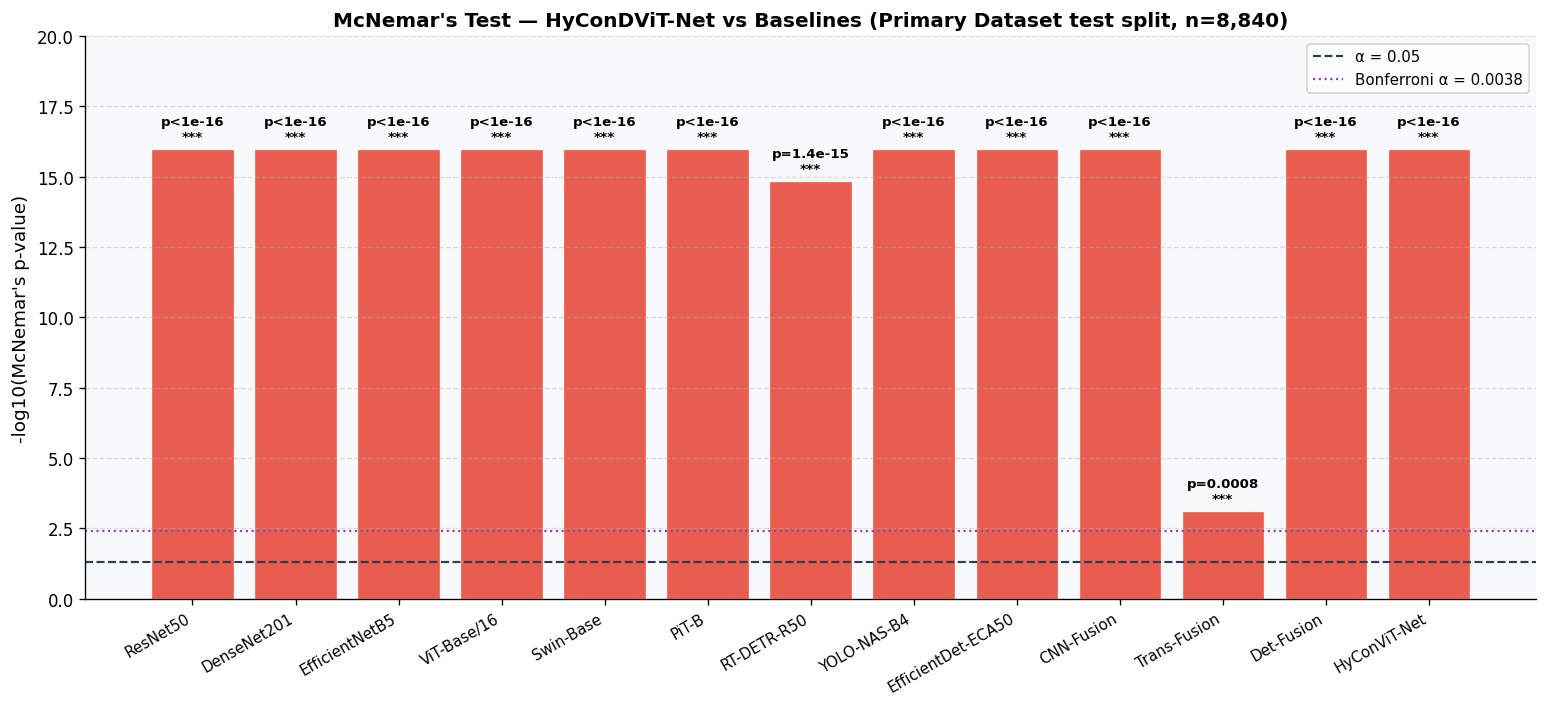

figA_mcnemar_pvalues.png


In [21]:
# ── Fig A: -log10(p), HyConDViT-Net vs each baseline ────────────────
# NOTE: most raw p-values here underflow to exactly 0.0 in float64 (true
# value is < ~1e-16) — plotting raw p on a linear axis makes almost every
# bar invisible. -log10(p) fixes that and matches Fig C's scale. Bar
# labels still show the honest p-value string (via fmt_p), not the
# transformed number.
LOG_FLOOR = 1e-16  # float64 precision floor, matches fmt_p's threshold — not an arbitrary display trick

pvals_raw  = [mcnemar_lookup[m]['p_value'] for m in BASELINES]
neglogp    = [-np.log10(max(p, LOG_FLOOR)) for p in pvals_raw]
pvals_disp = [mcnemar_lookup[m]['p_value_display'] for m in BASELINES]
stars      = [mcnemar_lookup[m]['sig_uncorrected'] for m in BASELINES]
colors     = ['#E74C3C' if p < 0.05 else '#95A5A6' for p in pvals_raw]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(BASELINES, neglogp, color=colors, edgecolor='white', linewidth=0.8, alpha=0.9)
for bar, p_str, s in zip(bars, pvals_disp, stars):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(neglogp)*0.02,
            f'{p_str}\n{s}', ha='center', fontsize=8, fontweight='bold')
ax.axhline(-np.log10(0.05), color='#2C3E50', linestyle='--', linewidth=1.3, label='α = 0.05')
ax.axhline(-np.log10(alpha_bonf), color='#8E44AD', linestyle=':', linewidth=1.3,
           label=f'Bonferroni α = {alpha_bonf:.4f}')
ax.set_ylabel("-log10(McNemar's p-value)")
ax.set_title(f"McNemar's Test — {FLAGSHIP} vs Baselines (Primary Dataset test split, n={len(y_true):,})",
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(BASELINES)))
ax.set_xticklabels(BASELINES, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, max(neglogp)*1.25)
ax.legend(loc='upper right', fontsize=9)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figA_mcnemar_pvalues.png', dpi=300, bbox_inches='tight')
plt.show()
print("figA_mcnemar_pvalues.png")

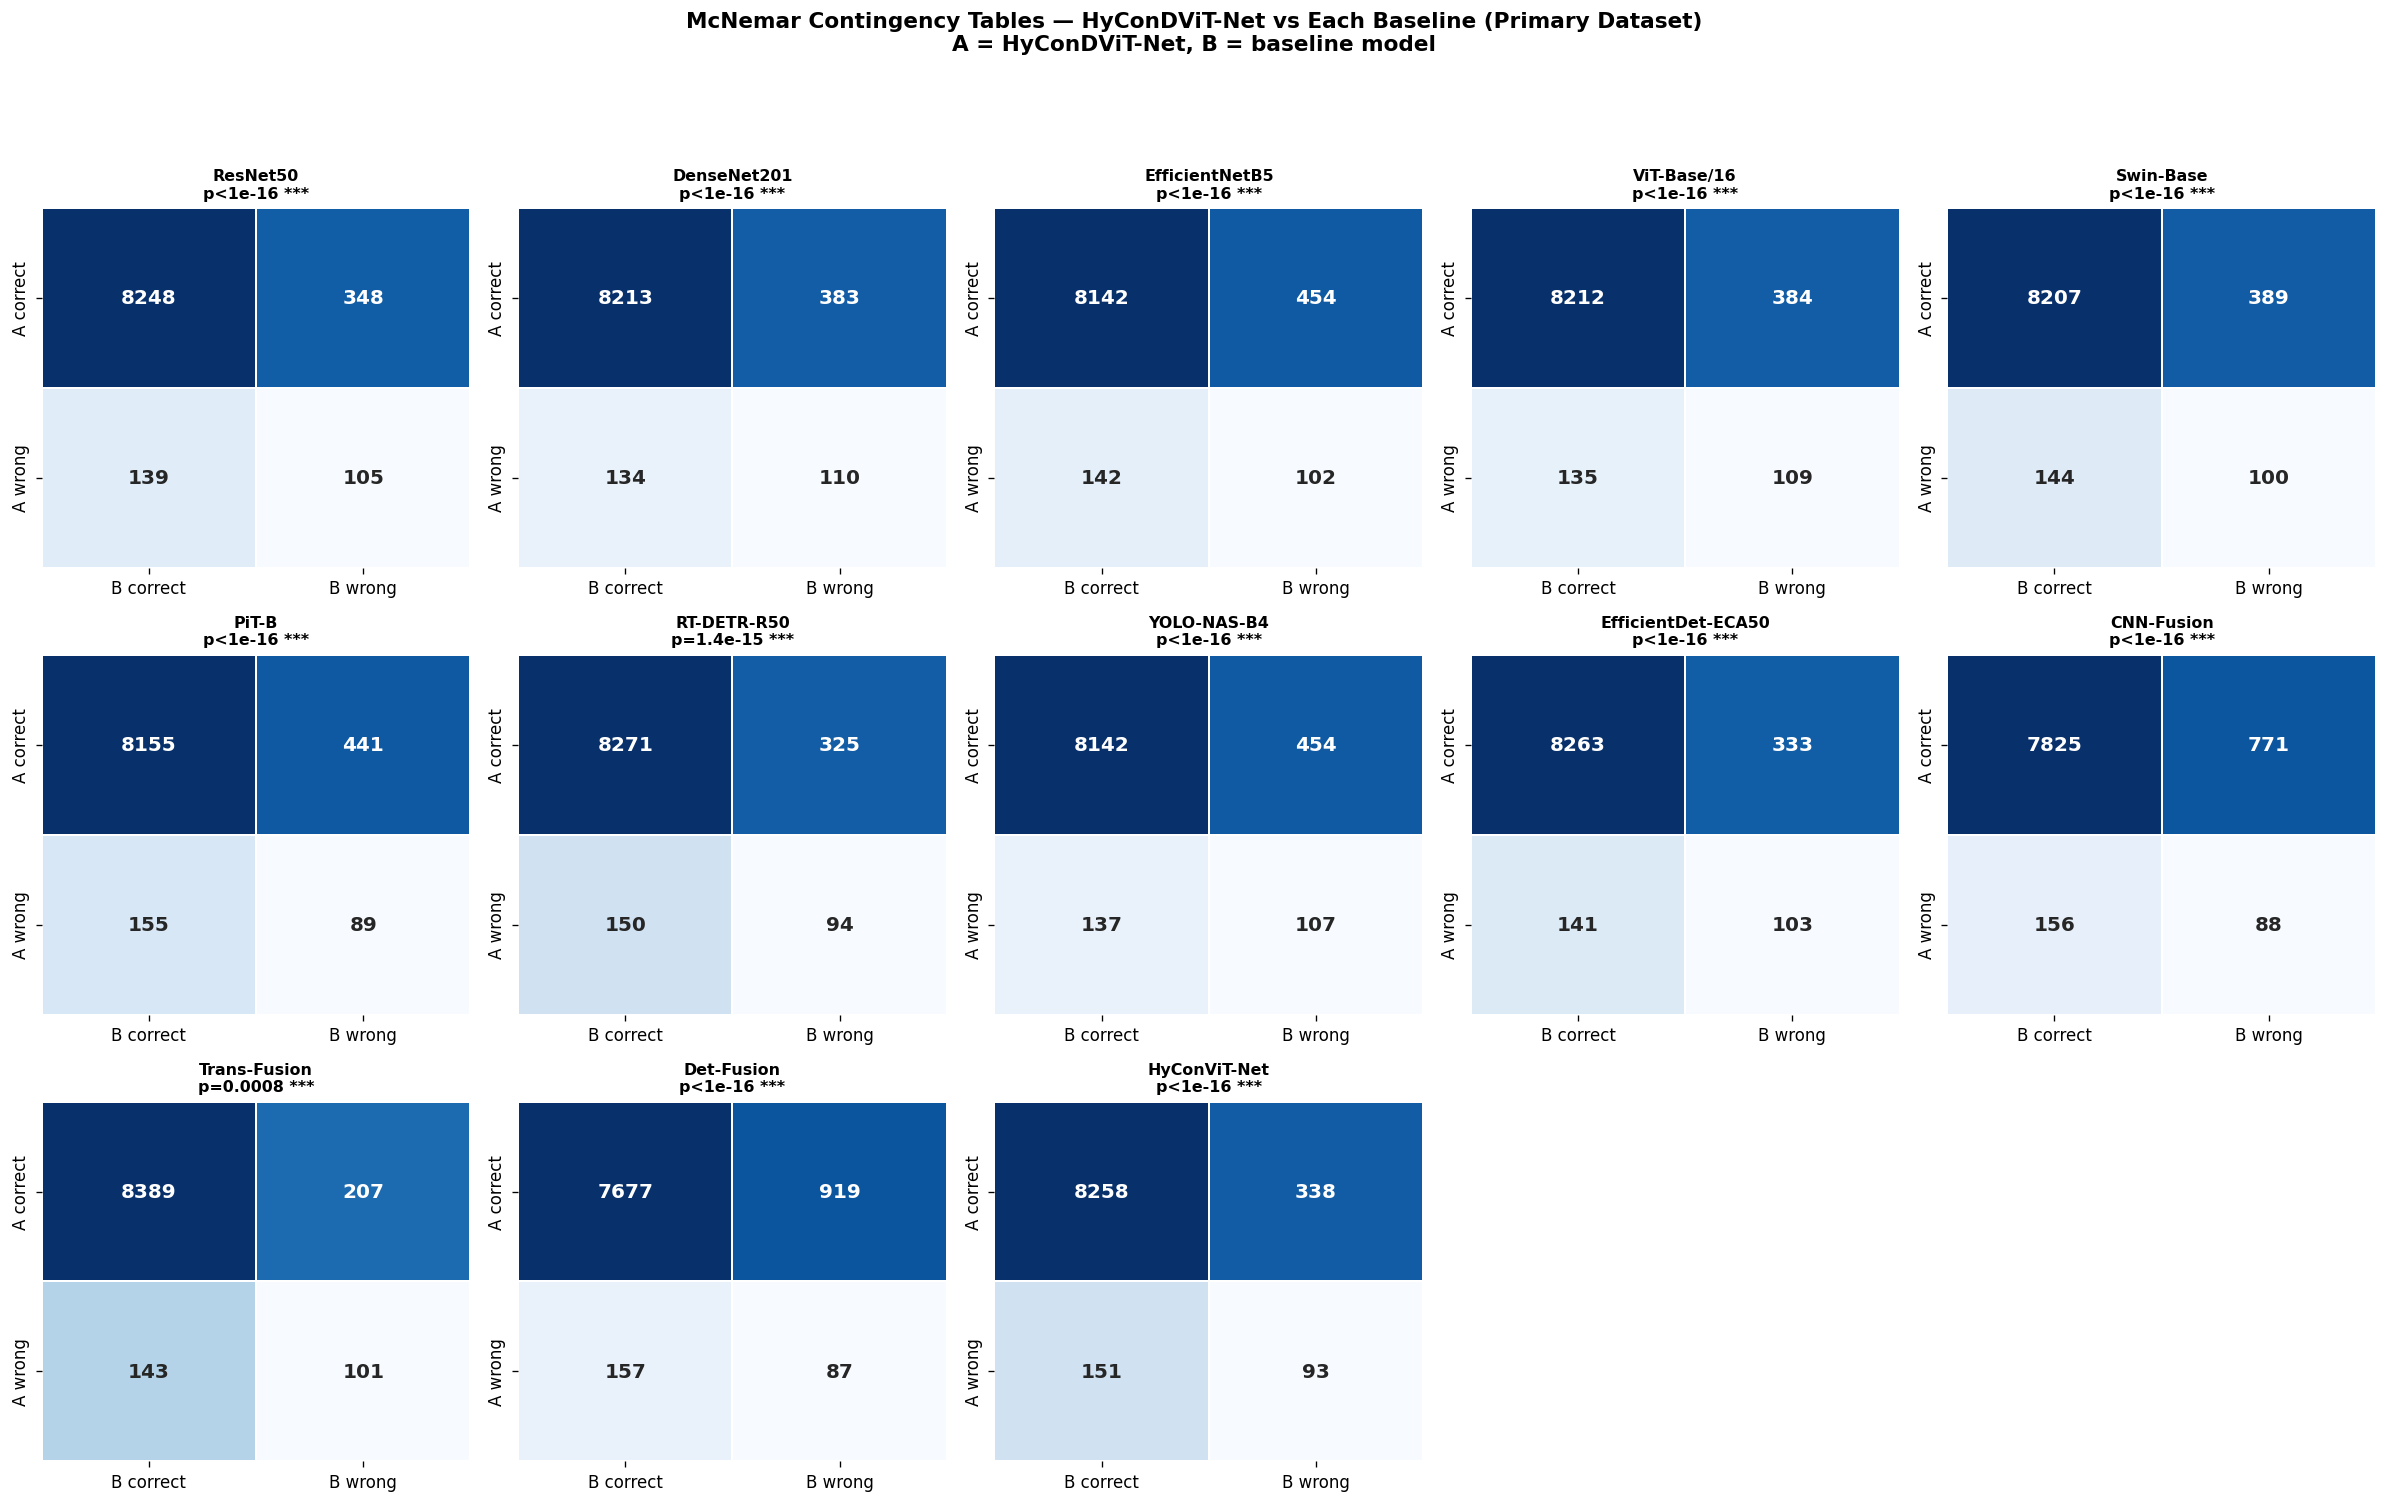

figB_mcnemar_contingency_grid.png


In [22]:
# ── Fig B: contingency table grid — HyConDViT-Net vs each baseline ──
fig, axes = plt.subplots(3, 5, figsize=(20, 13))
fig.suptitle(f"McNemar Contingency Tables — {FLAGSHIP} vs Each Baseline (Primary Dataset)\n"
             "A = HyConDViT-Net, B = baseline model",
             fontsize=13, fontweight='bold')

for ax, baseline in zip(axes.flat, BASELINES):
    r = mcnemar_lookup[baseline]
    table = np.array([[r['n11'], r['n10_A_only']],
                       [r['n01_B_only'], r['n00']]])
    # Color-scale using only the three "interesting" cells (b, c, both-wrong).
    # The "both correct" cell (n11) is usually ~90%+ of the test set, and
    # coloring all four cells on one shared scale crushes the differences
    # between b/c/both-wrong that we actually care about. n11's true count
    # still prints — it just clips to the top of the color range.
    vmax_local = max(r['n10_A_only'], r['n01_B_only'], r['n00']) * 1.15
    sns.heatmap(table, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                vmax=vmax_local,
                xticklabels=['B correct', 'B wrong'],
                yticklabels=['A correct', 'A wrong'],
                linewidths=1.0, linecolor='white', annot_kws={'size':12,'weight':'bold'})
    ax.set_title(f"{baseline}\n{r['p_value_display']} {r['sig_uncorrected']}", fontsize=9.5)

for ax in axes.flat[len(BASELINES):]:
    ax.axis('off')

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.savefig('figB_mcnemar_contingency_grid.png', dpi=300, bbox_inches='tight')
plt.show()
print("figB_mcnemar_contingency_grid.png")

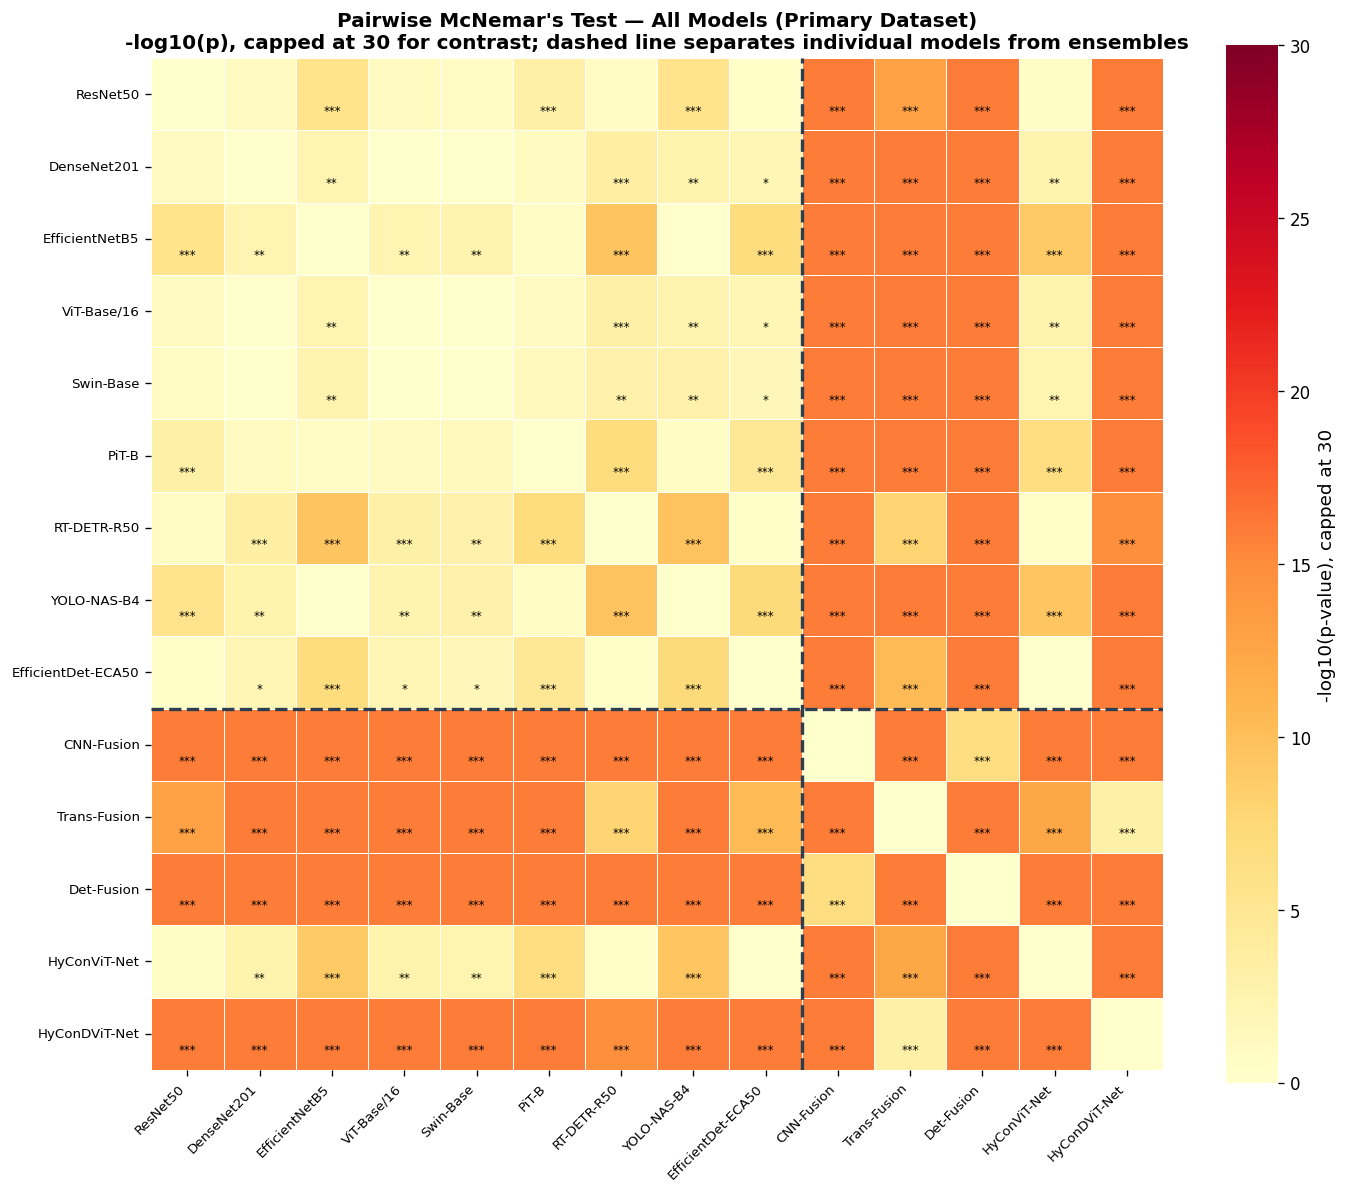

figC_mcnemar_pairwise_heatmap.png


In [23]:
# ── Fig C: full pairwise p-value heatmap, all 14 models ─────────────
# A handful of comparisons are so extreme (-log10(p) ~ 300) that an
# uncapped color scale crushes everything else — including the real,
# meaningful variation among the individual-model comparisons — into
# near-uniform pale yellow. Capping the color scale restores contrast
# where it matters; capped cells are still clearly "very significant"
# via their star annotation and saturated color, just not distinguishable
# from each other by shade (which wouldn't be a meaningful distinction
# anyway at p < 1e-30 vs p < 1e-300).
fig, ax = plt.subplots(figsize=(12, 10))
neglog_p = -np.log10(pmat.clip(lower=1e-16))  # 1e-16 = float64 p-value floor (matches fmt_p)
VMAX_CAP = 30
sns.heatmap(neglog_p, cmap='YlOrRd', ax=ax, square=True, linewidths=0.4, linecolor='white',
            cbar_kws={'label': f'-log10(p-value), capped at {VMAX_CAP}'}, vmin=0, vmax=VMAX_CAP)

for i, a in enumerate(model_keys):
    for j, b in enumerate(model_keys):
        if i == j: continue
        s = sig_stars(pmat.loc[a, b])
        if s != 'ns':
            txt_color = 'white' if neglog_p.loc[a, b] > VMAX_CAP*0.6 else 'black'
            ax.text(j+0.5, i+0.72, s, ha='center', va='center', fontsize=7, color=txt_color)

ax.axhline(len(ALL_NAMES), color='#2C3E50', linewidth=2, linestyle='--')
ax.axvline(len(ALL_NAMES), color='#2C3E50', linewidth=2, linestyle='--')
ax.set_title("Pairwise McNemar's Test — All Models (Primary Dataset)\n"
             f"-log10(p), capped at {VMAX_CAP} for contrast; dashed line separates individual models from ensembles",
             fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('figC_mcnemar_pairwise_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("figC_mcnemar_pairwise_heatmap.png")

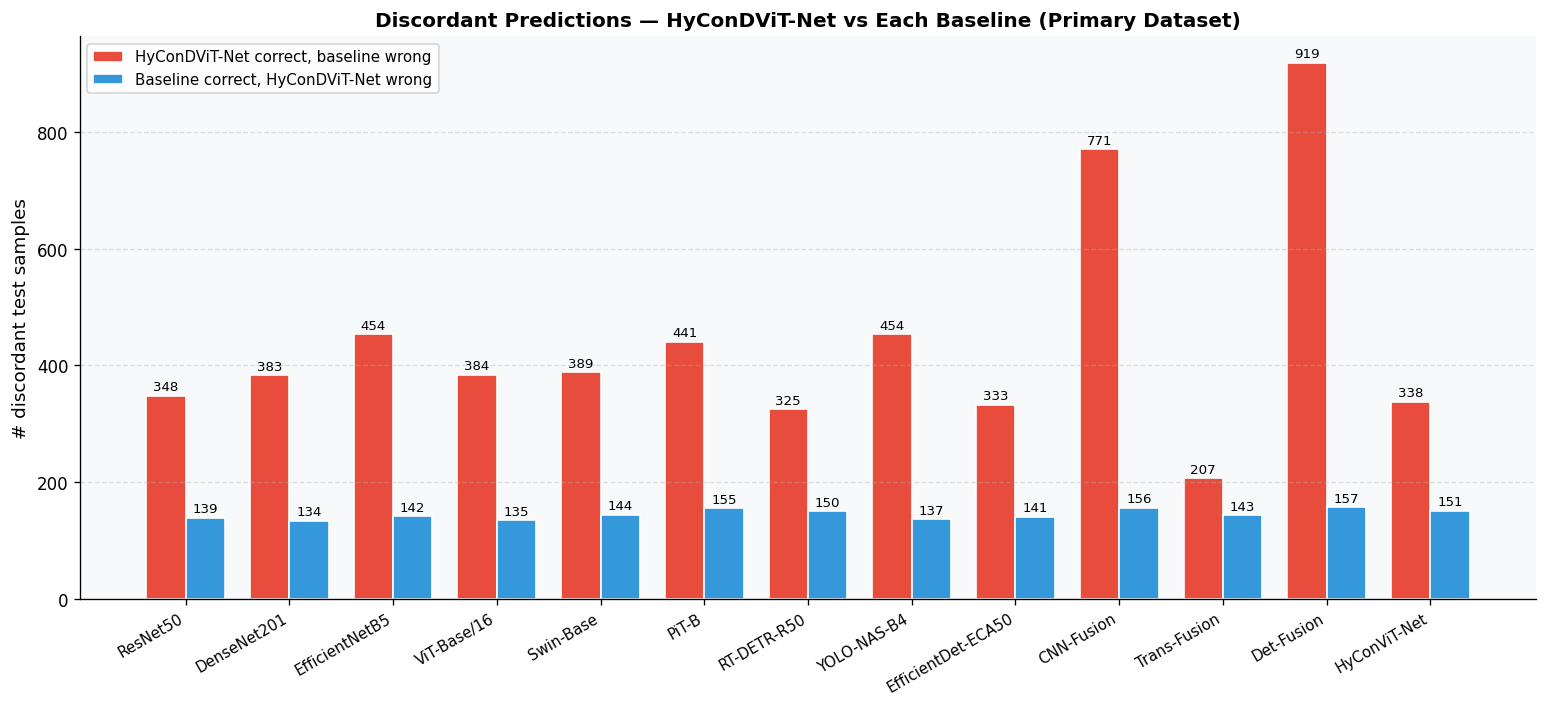

figD_mcnemar_discordant_pairs.png


In [24]:
# ── Fig D: discordant predictions — HyConDViT-Net vs each baseline ──
b_vals = [mcnemar_lookup[m]['n10_A_only'] for m in BASELINES]  # HyConDViT-Net correct, baseline wrong
c_vals = [mcnemar_lookup[m]['n01_B_only'] for m in BASELINES]  # baseline correct, HyConDViT-Net wrong

x = np.arange(len(BASELINES)); w = 0.38
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w/2, b_vals, width=w, label=f'{FLAGSHIP} correct, baseline wrong',
       color='#E74C3C', edgecolor='white')
ax.bar(x + w/2, c_vals, width=w, label=f'Baseline correct, {FLAGSHIP} wrong',
       color='#3498DB', edgecolor='white')
for xi, bv, cv in zip(x, b_vals, c_vals):
    ax.text(xi - w/2, bv + max(b_vals+c_vals)*0.01, str(bv), ha='center', fontsize=8)
    ax.text(xi + w/2, cv + max(b_vals+c_vals)*0.01, str(cv), ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(BASELINES, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('# discordant test samples')
ax.set_title(f"Discordant Predictions — {FLAGSHIP} vs Each Baseline (Primary Dataset)",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figD_mcnemar_discordant_pairs.png', dpi=300, bbox_inches='tight')
plt.show()
print("figD_mcnemar_discordant_pairs.png")

## Confusion Matrices (Individual + Ensemble Models)

McNemar's test tells you *whether* HyConDViT-Net's errors differ from a baseline's — these confusion matrices show *what those errors actually are* (false positives vs false negatives) for every model on the same Primary-dataset test split.

In [25]:
from sklearn.metrics import confusion_matrix

CLASS_NAMES = ['Non-Infected', 'Infected']

def annotate_cm(cm):
    """Two-line cell text: raw count, and % of that cell's TRUE row (i.e. sensitivity/specificity readable directly)."""
    row_sums = cm.sum(axis=1, keepdims=True)
    pct = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0) * 100
    return np.array([[f"{cm[i,j]:,}\n({pct[i,j]:.1f}%)" for j in range(cm.shape[1])]
                      for i in range(cm.shape[0])])

def cm_stats(labels, preds):
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    acc  = (tp + tn) / cm.sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # sensitivity
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return cm, acc, prec, rec, spec

print("Confusion-matrix helpers defined.")

Confusion-matrix helpers defined.


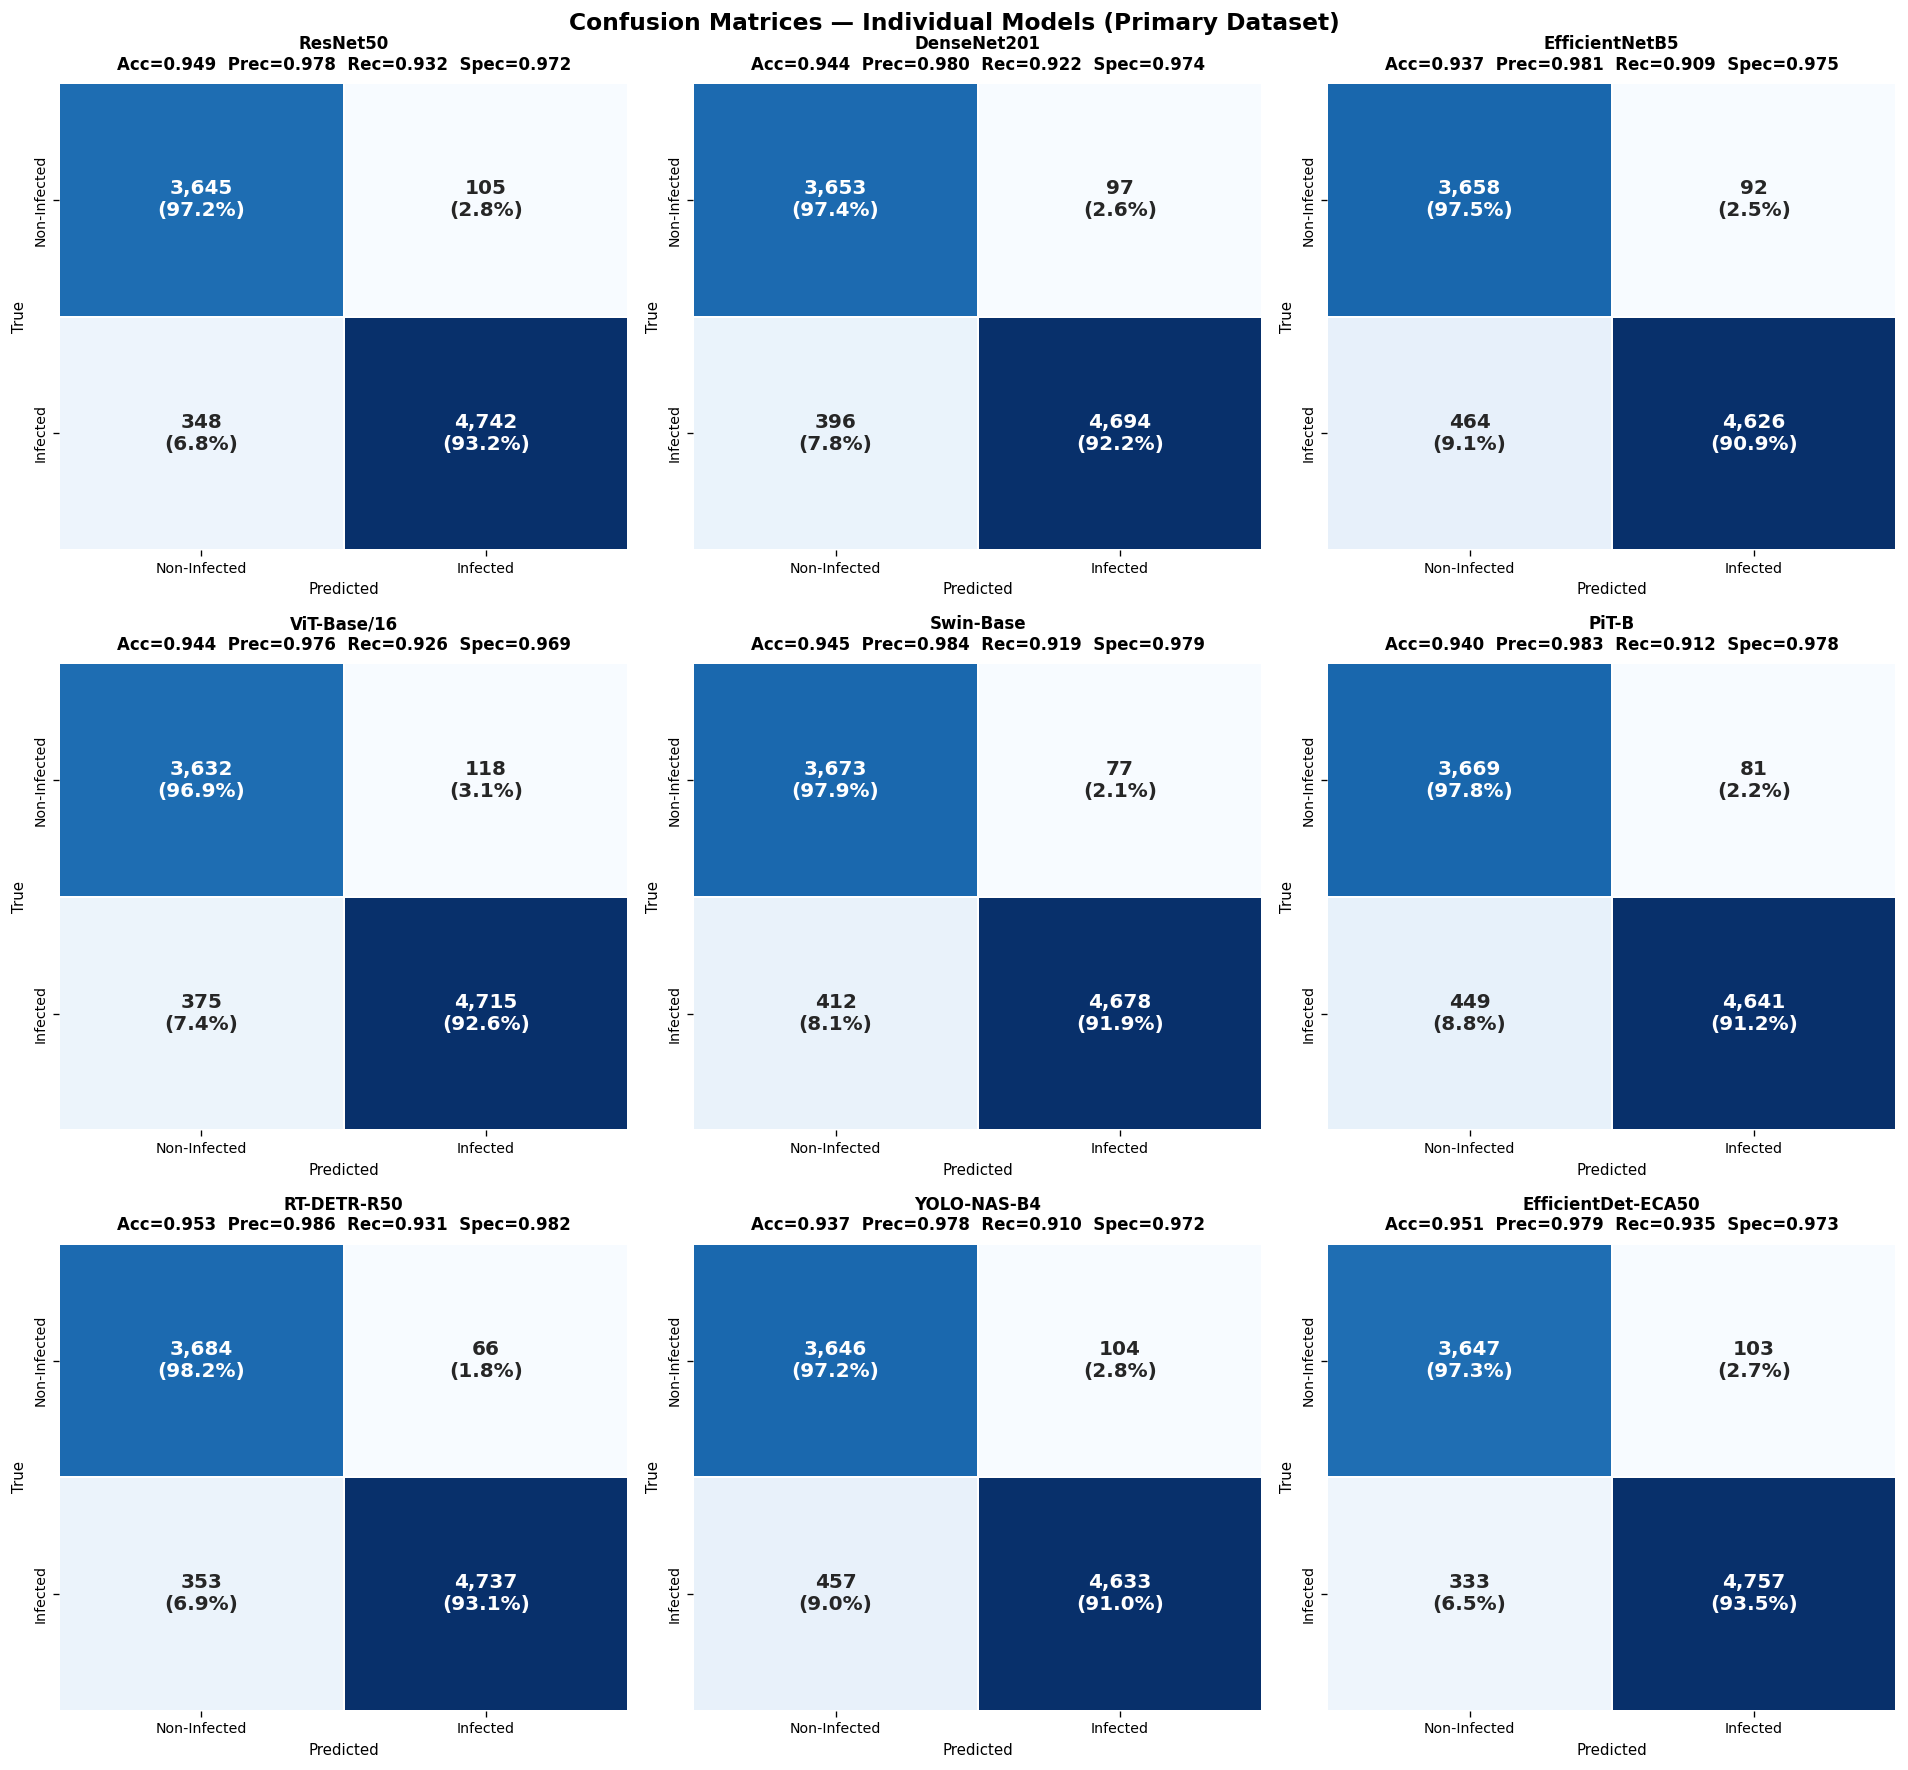

figE_cm_individual.png


In [26]:
# ── Fig E: Confusion Matrices — Individual Models ────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 15))
fig.suptitle("Confusion Matrices — Individual Models (Primary Dataset)",
             fontsize=14, fontweight='bold')

for ax, nm in zip(axes.flat, ALL_NAMES):
    met = ind_metrics[nm]
    cm, acc, prec, rec, spec = cm_stats(met['labels'], met['preds'])
    sns.heatmap(cm, annot=annotate_cm(cm), fmt='', cmap='Blues', ax=ax, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=1.2, linecolor='white',
                annot_kws={'size': 12, 'weight': 'bold'})
    ax.set_title(f"{MODEL_DISPLAY[nm]}\n"
                 f"Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  Spec={spec:.3f}",
                 fontsize=10, pad=8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(labelsize=8.5)

plt.tight_layout()
plt.savefig('figE_cm_individual.png', dpi=300, bbox_inches='tight')
plt.show()
print("figE_cm_individual.png")

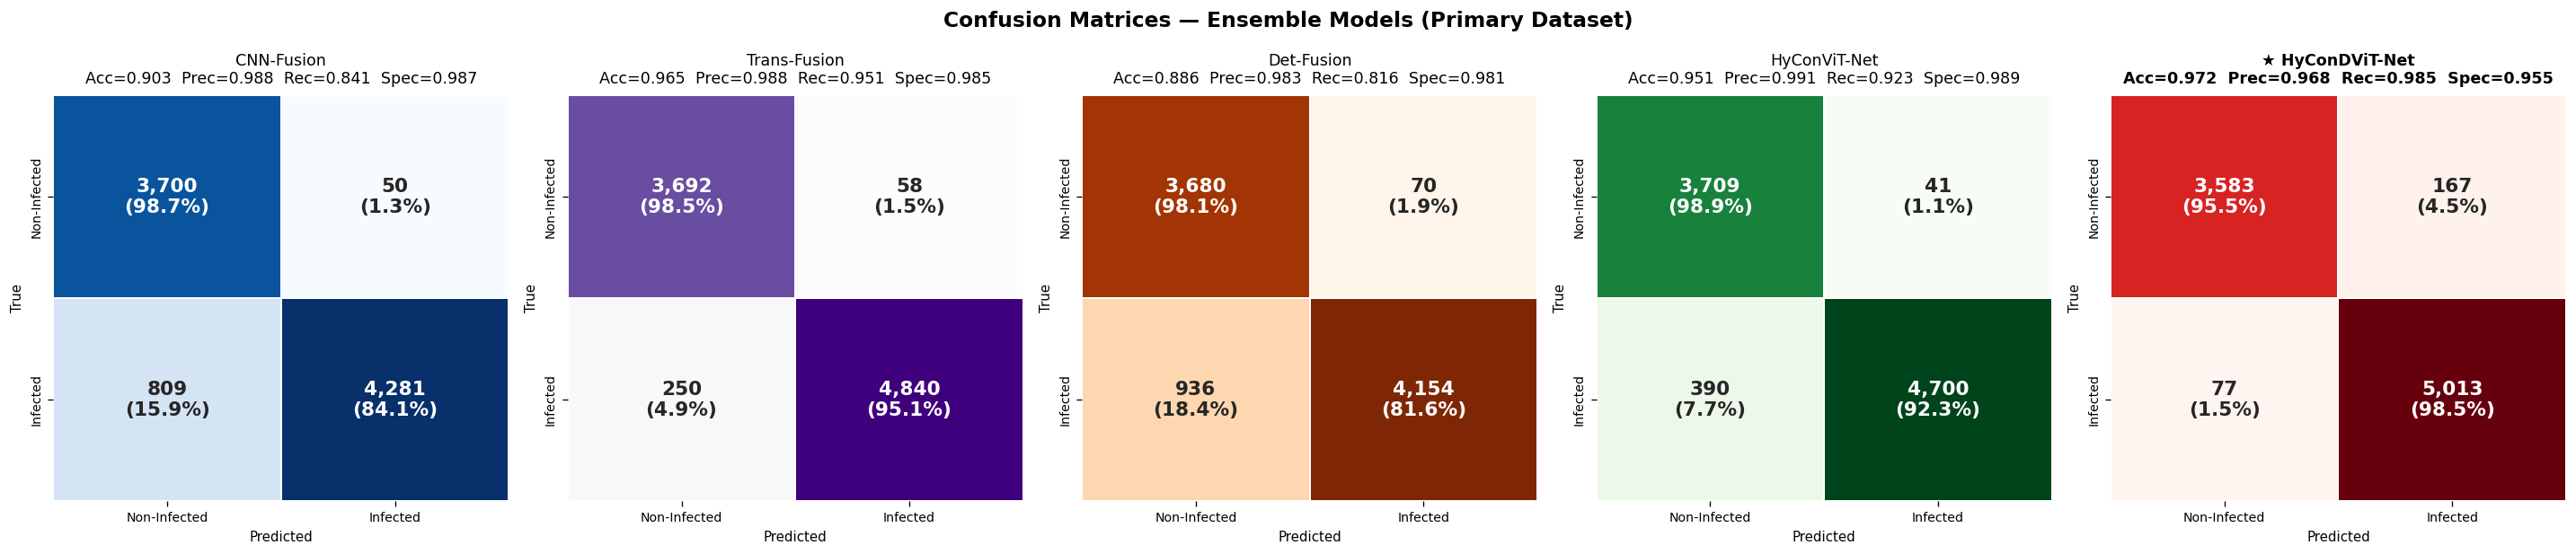

figF_cm_ensemble.png


In [27]:
# ── Fig F: Confusion Matrices — Ensemble Models ──────────────────
# cmaps assigned per model, as requested:
#   Blues = CNN-Fusion, Purples = Trans-Fusion, Oranges = Det-Fusion,
#   Greens = HyConViT-Net, Reds = HyConDViT-Net (flagship)
ensemble_order = ['CNN-Fusion', 'Trans-Fusion', 'Det-Fusion', 'HyConViT-Net', 'HyConDViT-Net']
ensemble_cmaps = ['Blues', 'Purples', 'Oranges', 'Greens', 'Reds']

fig, axes = plt.subplots(1, 5, figsize=(24, 5.2))
fig.suptitle("Confusion Matrices — Ensemble Models (Primary Dataset)",
             fontsize=14, fontweight='bold')

for ax, label, cmap in zip(axes, ensemble_order, ensemble_cmaps):
    met = ens_metrics[label]
    cm, acc, prec, rec, spec = cm_stats(met['labels'], met['preds'])
    sns.heatmap(cm, annot=annotate_cm(cm), fmt='', cmap=cmap, ax=ax, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=1.2, linecolor='white',
                annot_kws={'size': 13, 'weight': 'bold'})
    star = '\u2605 ' if label == FLAGSHIP else ''
    ax.set_title(f"{star}{label}\n"
                 f"Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  Spec={spec:.3f}",
                 fontsize=10.5, pad=8, fontweight='bold' if label == FLAGSHIP else 'normal')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(labelsize=8.5)

plt.tight_layout()
plt.savefig('figF_cm_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()
print("figF_cm_ensemble.png")

## Save Results

In [28]:
df_flagship.to_csv('mcnemar_results_primary_flagship_vs_baselines.csv', index=False)
pmat.to_csv('mcnemar_pvalue_matrix_primary.csv')
bmat.to_csv('mcnemar_discordant_matrix_primary.csv')
summary.to_csv('model_accuracy_summary_primary.csv', index=False)

print("✅ Saved:")
print("   mcnemar_results_primary_flagship_vs_baselines.csv")
print("   mcnemar_pvalue_matrix_primary.csv")
print("   mcnemar_discordant_matrix_primary.csv")
print("   model_accuracy_summary_primary.csv")
print()
print("📁 Figures:")
for f in ['figA_mcnemar_pvalues','figB_mcnemar_contingency_grid',
          'figC_mcnemar_pairwise_heatmap','figD_mcnemar_discordant_pairs',
          'figE_cm_individual','figF_cm_ensemble']:
    print(f"   {f}.png")

✅ Saved:
   mcnemar_results_primary_flagship_vs_baselines.csv
   mcnemar_pvalue_matrix_primary.csv
   mcnemar_discordant_matrix_primary.csv
   model_accuracy_summary_primary.csv

📁 Figures:
   figA_mcnemar_pvalues.png
   figB_mcnemar_contingency_grid.png
   figC_mcnemar_pairwise_heatmap.png
   figD_mcnemar_discordant_pairs.png
   figE_cm_individual.png
   figF_cm_ensemble.png


In [29]:
# GPU Status — End of Notebook
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "nvidia-smi not available")

Sun Jul 26 15:23:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             31W /   70W |     159MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----